## Titanic Data Pre-processing

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#read data Titanic
df = pd.read_csv('Titanic.csv')

In [4]:
df.head()  # view first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape #check the number of rows and columns

(891, 12)

In [6]:
df.info()  #know information about the columns, data types, and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 1. Data Understanding (فهم البيانات)

In [7]:
# these columns don't help us predict Survived so we drop them
DROP_COLUMNS = ["PassengerId", "Name", "Ticket"]

df.drop(DROP_COLUMNS, axis=1, inplace=True, errors='ignore') #To drop specific columns from a DataFrame
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [8]:
def drop_cols(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Drop specific columns from a DataFrame.
    (this is the same function i put in pro.py so main.py can use it)
    """
    return df.drop(columns=cols, errors='ignore')

### 2. Check for Datatypes (فحص أنواع البيانات)

In [9]:
dtypes = df.dtypes # get the data type of each column
n_uniq = df.nunique() # count the number of unique values in each column
pd.DataFrame({"Dtypes": dtypes, "Num_unique": n_uniq}).T #show data types and number of unique values together

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
Num_unique,2,3,2,88,7,7,248,147,3


In [10]:
# these columns have a small number of unique values so they are actually categorical, not numbers/strings
cols = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked"]
df[cols] = df[cols].astype("category")
pd.DataFrame(df.dtypes).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,category,category,category,float64,category,category,float64,object,category


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    category
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    category
 5   Parch     891 non-null    category
 6   Fare      891 non-null    float64 
 7   Cabin     204 non-null    object  
 8   Embarked  889 non-null    category
dtypes: category(6), float64(2), object(1)
memory usage: 27.4+ KB


### 3. Handle Null Values (التعامل مع القيم المفقودة)

In [12]:
df.isnull().sum() # check how many nulls in each column

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [13]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100 # null values as a percentage
pd.DataFrame({"null": null, "ratio": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [14]:
# Embarked has only 2 nulls so we just drop these rows
df = df.dropna(subset=['Embarked'])
df.isnull().sum() # check again after dropping

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      0
dtype: int64

In [16]:
# Cabin has too many nulls (around 77%) so we drop the whole column instead
df = df.drop("Cabin", axis=1, errors='ignore')

In [17]:
# Age has about 20% nulls, and its distribution is skewed (not normal)
# so we fill the nulls with the median instead of the mean
median = df['Age'].median()
df['Age'] = df['Age'].fillna(median)
df.isnull().sum() # make sure no nulls left

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### 4. Handle Outliers (التعامل مع القيم الشاذة)

In [ ]:
num_cols = df.select_dtypes("number").columns

# check the outliers before fixing them
plt.figure(figsize=(8, 3))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot (before)")
plt.show()

In [19]:
num_cols = df.select_dtypes("number").columns

In [20]:
# fix the outliers using the IQR method
# any value above the upper fence or below the lower fence gets clipped to the fence value
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_fence, upper=upper_fence)

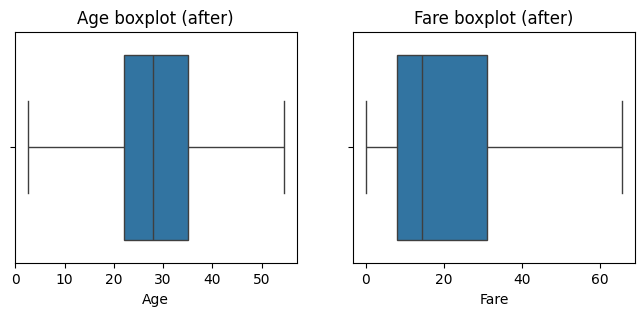

In [21]:
# check the outliers again after fixing them
plt.figure(figsize=(8, 3))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot (after)")
plt.show()

### 5. Remove Duplicates (إزالة التكرار)

In [22]:
# 1. check
df.duplicated().sum()

np.int64(129)

In [23]:
# 2. remove
df.drop_duplicates(inplace=True)

# 3. confirm
df.duplicated().sum()

np.int64(0)

### 6. Visualization (التصوير البياني)

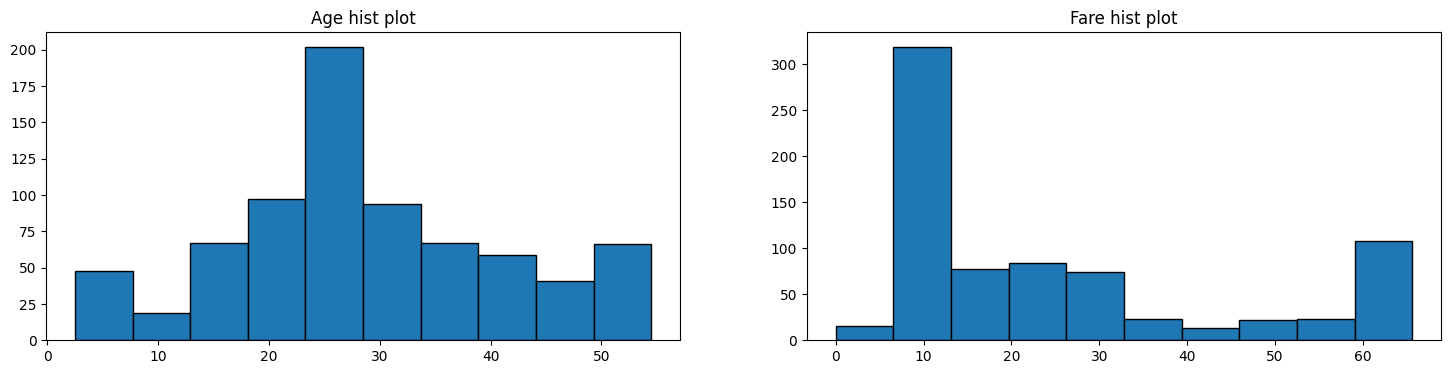

In [24]:
# numerical columns distribution (histogram)
plt.figure(figsize=(9 * len(num_cols), 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} hist plot")
plt.show()

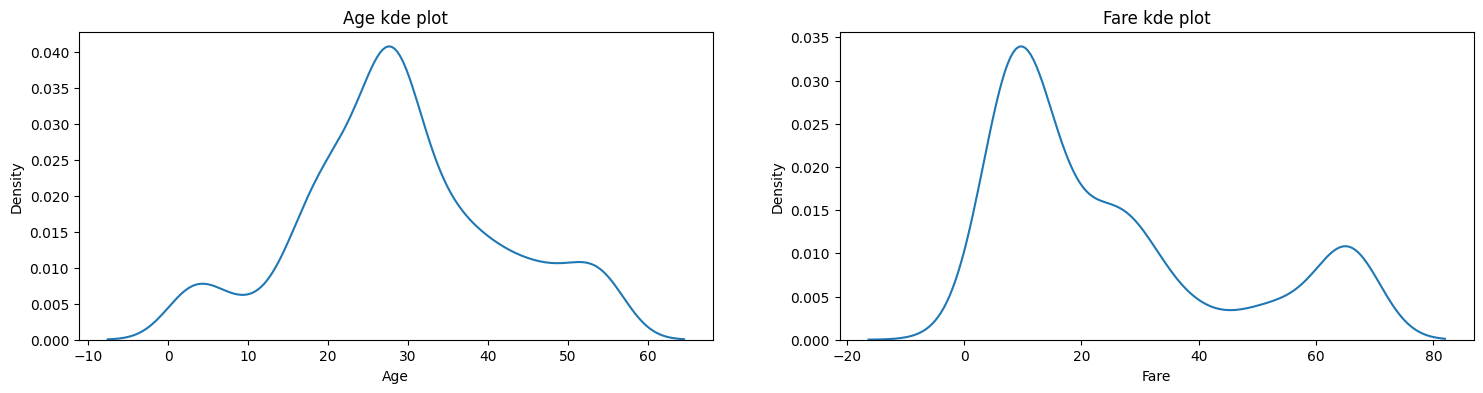

In [25]:
# numerical columns distribution (kde plot)
plt.figure(figsize=(9 * len(num_cols), 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i + 1)
    sns.kdeplot(df[col])
    plt.title(f"{col} kde plot")
plt.show()

In [26]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='object')

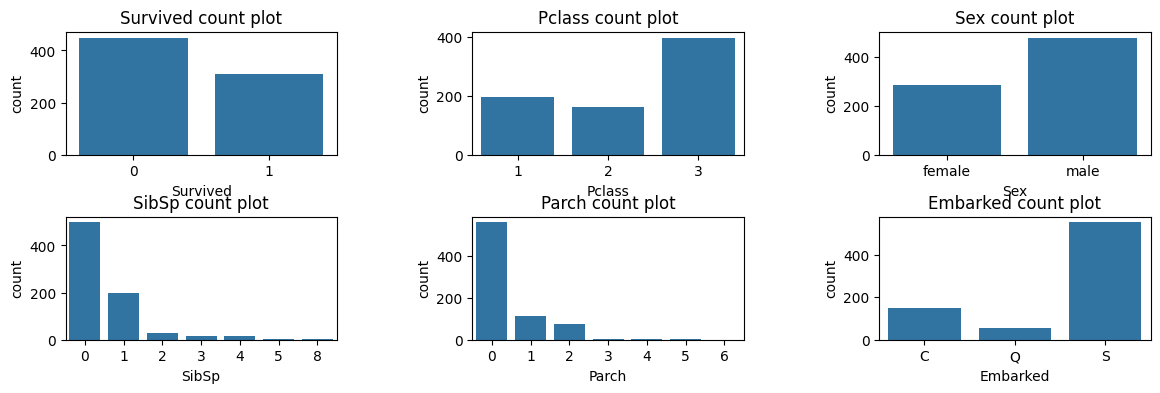

In [27]:
# categorical columns distribution (count plot)
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} count plot")
plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.show()

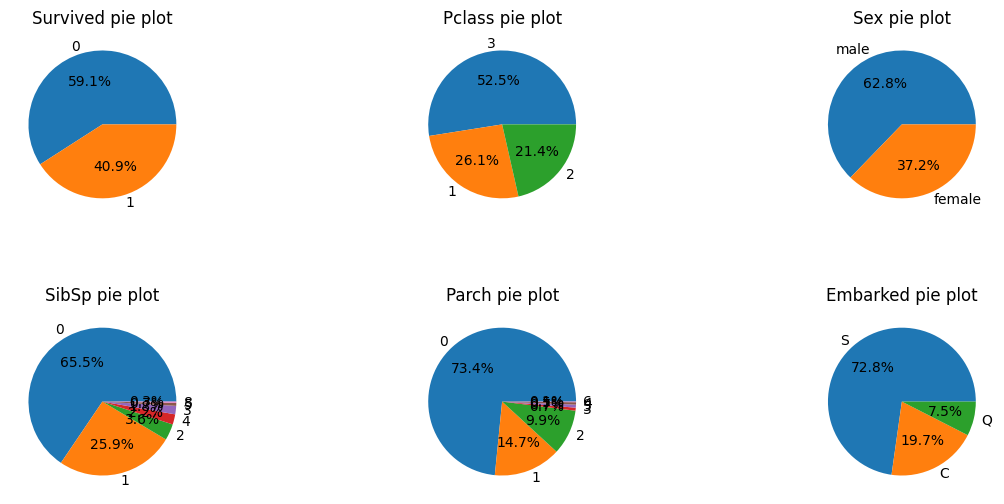

In [33]:
# categorical columns distribution (pie plot)
plt.figure(figsize=(14, 6))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels=categories, autopct="%1.1f%%")
    plt.title(f"{col} pie plot")
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

<Figure size 1200x1200 with 0 Axes>

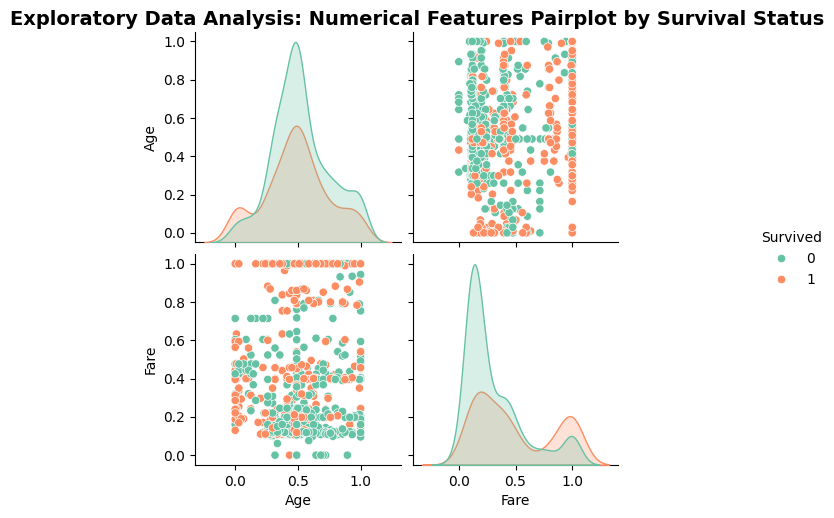

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visualization canvas for numerical features vs target distribution
plt.figure(figsize=(12, 12))

# Map numerical correlations and feature distributions, highlighting survival outcomes
sns.pairplot(
    X[num_cols].join(df["Survived"]), hue="Survived", palette="Set2", diag_kind="kde"
)

# Add a descriptive main title to clearly present the exploratory analysis
plt.suptitle(
    "Exploratory Data Analysis: Numerical Features Pairplot by Survival Status",
    y=1.02,
    fontsize=14,
    weight="bold",
)

plt.show()

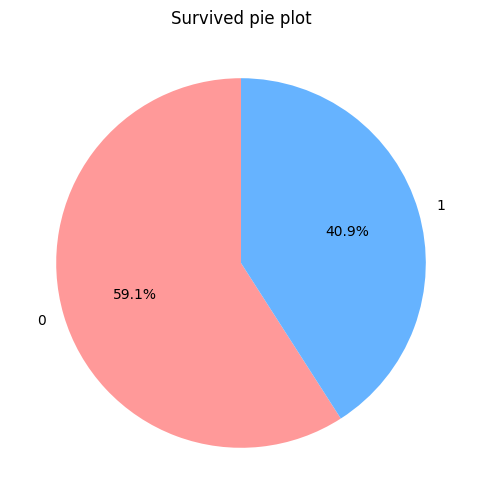

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
df["Survived"].value_counts().plot.pie(
    autopct="%1.1f%%", startangle=90, colors=["#ff9999", "#66b3ff"]
)
plt.title("Survived pie plot")
plt.ylabel("")
plt.show()

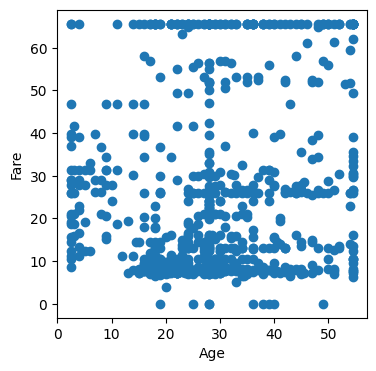

In [35]:
# relationship between two numerical columns (scatter plot)
plt.figure(figsize=(4, 4))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

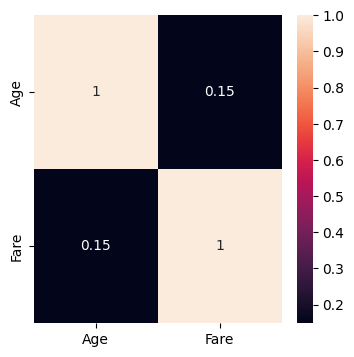

In [36]:
# correlation between numerical columns (heat map)
corr = df[num_cols].corr()
plt.figure(figsize=(4, 4))
sns.heatmap(corr, annot=True)
plt.show()

### 7. Data Splitting (تقسيم البيانات لـ Features و Target)

In [37]:
# split the data into Features (X) and Target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]

### 8. Normalization (التحجيم / Scaling)

X_new = (X - Min) / (Max - Min)

In [38]:
from sklearn.preprocessing import MinMaxScaler

# scale the numerical columns to be between 0 and 1
num_cols = X.select_dtypes("number").columns
scaler = MinMaxScaler()
scaler.fit(X[num_cols])
X[num_cols] = scaler.transform(X[num_cols])
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.375000,1,0,0.110424,S
1,1,female,0.682692,1,0,1.000000,C
2,3,female,0.451923,0,0,0.120704,S
3,1,female,0.625000,1,0,0.808757,S
4,3,male,0.625000,0,0,0.122608,S


### 9. Encoding (تحويل النصوص لأرقام)

In [39]:
from category_encoders import OneHotEncoder

# Sex and Embarked are the only nominal string columns, so only these need encoding
str_cols = ["Sex", "Embarked"]
encoder = OneHotEncoder(cols=str_cols, drop_invariant=True)
X = encoder.fit_transform(X)
X.head()

,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Embarked_1,Embarked_2,Embarked_3
0,3,1,0,0.375000,1,0,0.110424,1,0,0
1,1,0,1,0.682692,1,0,1.000000,0,1,0
2,3,0,1,0.451923,0,0,0.120704,1,0,0
3,1,0,1,0.625000,1,0,0.808757,1,0,0
4,3,1,0,0.625000,0,0,0.122608,1,0,0


In [40]:
# final check before modeling
print(X.shape)
print(y.shape)

(760, 10)
(760,)
